In [ ]:
import numpy as np
import torch

path = "/AILAB-summer-school-2025/RND/checkpoints/[ensemble]rnd_iter100_balance_False_epoch_10_alpha_0.95_minDemo70_H0_FTrue/expert_dataset_100.npz"

data = np.load(path)

# 안에 어떤 key들이 있는지 확인
print("Keys in npz file:", data.files)

# 대표적으로 states 기준으로 개수 확인
if "states" in data:
    print("Number of samples (states):", data["states"].shape[0])
    print("State shape per sample:", data["states"].shape[1:])
else:
    print("⚠️ 'states' key not found")

if "actions" in data:
    print("Number of samples (actions):", data["actions"].shape[0])
    print("Action shape per sample:", data["actions"].shape[1:])
else:
    print("⚠️ 'actions' key not found")

if "expert_actions" in data:
    print("Number of samples (expert_actions):", data["expert_actions"].shape[0])


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import time, os

log_path = "/AILAB-summer-school-2025/RND/ood_log.csv"

plt.ion()
fig, ax = plt.subplots(figsize=(10,5))
disp = display(fig, display_id=True)

last_size = 0
STEP_WINDOW = 2000 

while True:
    try:
        current_size = os.path.getsize(log_path)
    except:
        time.sleep(0.5)
        continue

    if current_size == last_size:
        time.sleep(0.2)
        continue
    last_size = current_size

    # ---------------------------------------
    # Load CSV and skip "EPISODE_END" lines
    # ---------------------------------------
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("EPISODE_END"):
                continue
            
            parts = line.strip().split(",")
            if len(parts) != 4:
                continue
            
            try:
                rows.append([
                    int(parts[0]),   # global_step
                    float(parts[1]), # lambda
                    float(parts[2]), # ood
                    int(parts[3])    # episode
                ])
            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(rows,
                      columns=["global_step","lambda","ood","episode"])

    latest_step = df["global_step"].iloc[-1]
    latest_ep = df["episode"].iloc[-1]

    # ---------------------------------------
    # Sliding window view (global_step 기준)
    # ---------------------------------------
    window_min = max(0, latest_step - STEP_WINDOW)
    df_window = df[df["global_step"] >= window_min]

    # ---------------------------------------
    # Plot (reset only axis, not figure)
    # ---------------------------------------
    ax.clear()

    ax.plot(df_window["global_step"], df_window["ood"], color="black")

    lambda_val = df_window["lambda"].iloc[-1]
    ax.axhline(lambda_val, linestyle='--', color='red',
               label=f"λ={lambda_val}")

    detections = df_window[df_window["ood"] > lambda_val].groupby("episode").first()
    for ep, row in detections.iterrows():
        ax.plot(row["global_step"], row["ood"], 'ro', markersize=5)

    # ---------------------------------------
    # Adjust x-axis to sliding window
    # ---------------------------------------
    ax.set_xlim(window_min, latest_step)

    ax.set_title(f"Real-time OOD Monitoring | Current Episode = {latest_ep}")
    ax.set_xlabel(f"Global Step (showing last {STEP_WINDOW})")
    ax.set_ylabel("OOD")
    ax.grid(True)
    ax.legend()

    disp.update(fig)
    time.sleep(0.1)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import time, os

log_path = "/AILAB-summer-school-2025/RND/ood_log.csv"

plt.ion()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=False)
disp = display(fig, display_id=True)

last_size = 0
STEP_WINDOW = 500   # only for OOD plot


while True:
    try:
        current_size = os.path.getsize(log_path)
    except:
        time.sleep(0.5)
        continue

    if current_size == last_size:
        time.sleep(0.2)
        continue
    last_size = current_size

    # ============================================
    # 1) Load CSV (skip EPISODE_END)
    # ============================================
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("EPISODE_END"):
                continue

            parts = line.strip().split(",")
            if len(parts) != 4:
                continue

            try:
                rows.append([
                    int(parts[0]),   # global_step
                    float(parts[1]), # lambda
                    float(parts[2]), # ood
                    int(parts[3])    # episode
                ])
            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(rows,
                      columns=["global_step","lambda","ood","episode"])

    latest_step   = df["global_step"].iloc[-1]
    latest_ep     = df["episode"].iloc[-1]
    latest_lambda = df["lambda"].iloc[-1]
    latest_ood    = df["ood"].iloc[-1]

    # ============================================
    # 2) 500-step sliding window (for OOD only)
    # ============================================
    window_min = max(0, latest_step - STEP_WINDOW)
    df_window = df[df["global_step"] >= window_min]

    # ============================================
    # 3) Lambda Plot (upper) - FULL HISTORY
    # ============================================
    ax1.clear()

    # 전체 히스토리 (회색)
    ax1.plot(df["global_step"],
             df["lambda"],
             color="black",
             alpha=0.9,
             label="lambda history")

    # 현재 lambda
    ax1.plot(latest_step,
             latest_lambda,
             'ro',
             markersize=7,
             label="current λ")

    # ✅ Outlier 제거용 Y축 설정
    lam_values = df["lambda"].values
    lam_p99 = np.percentile(lam_values, 99)
    lam_min = np.percentile(lam_values, 1)

    ax1.set_ylim(lam_min * 0.95, lam_p99 * 1.2)

    ax1.set_ylabel("Lambda")
    ax1.set_title(f"Real-time Lambda & OOD | Current Episode = {latest_ep}")
    ax1.grid(True)
    ax1.legend()

    # ============================================
    # 4) OOD Plot (lower) - SLIDING WINDOW
    # ============================================
    ax2.clear()

    ax2.plot(df_window["global_step"],
             df_window["ood"],
             color="black",
             label="OOD")

    # Lambda threshold
    ax2.axhline(latest_lambda,
                linestyle='--',
                color='red',
                label=f"λ = {latest_lambda:.4f}")

    # ✅ OOD Y-axis clip
    ood_values = df_window["ood"].values
    if len(ood_values) > 5:
        ood_p99 = np.percentile(ood_values, 99)
        ax2.set_ylim(0, ood_p99 * 1.2)

    # Episode-wise detection
    detections = df_window[df_window["ood"] > latest_lambda] \
                    .groupby("episode").first()

    for ep, row in detections.iterrows():
        ax2.plot(row["global_step"],
                 row["ood"],
                 'ro',
                 markersize=5)

    # 🔗 connection between lambda plot and OOD plot
    ax2.plot([latest_step, latest_step],
             [latest_lambda, latest_ood],
             color="red",
             linestyle=":",
             linewidth=1)

    # X-limit only for sliding window
    ax2.set_xlim(window_min, latest_step)

    ax2.set_xlabel(f"Global Step (last {STEP_WINDOW} steps)")
    ax2.set_ylabel("OOD")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    disp.update(fig)

    time.sleep(0.1)

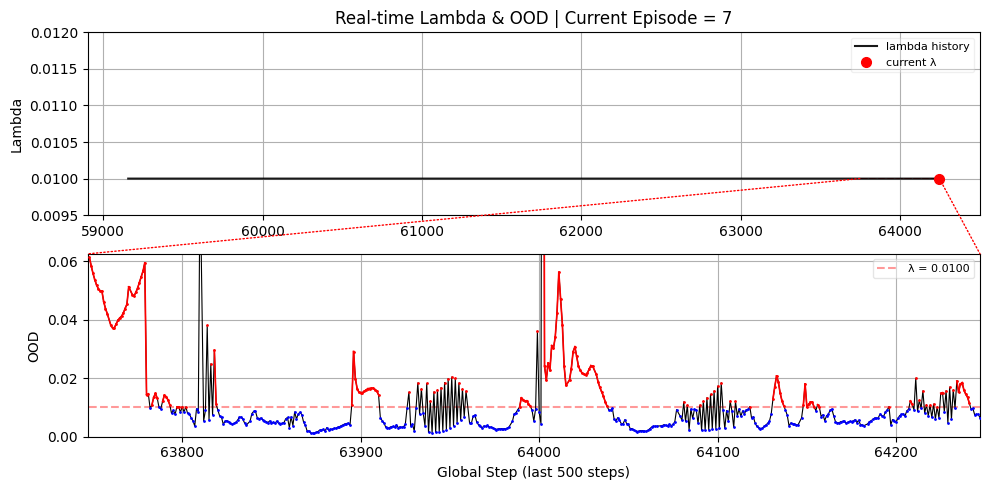

KeyboardInterrupt: 

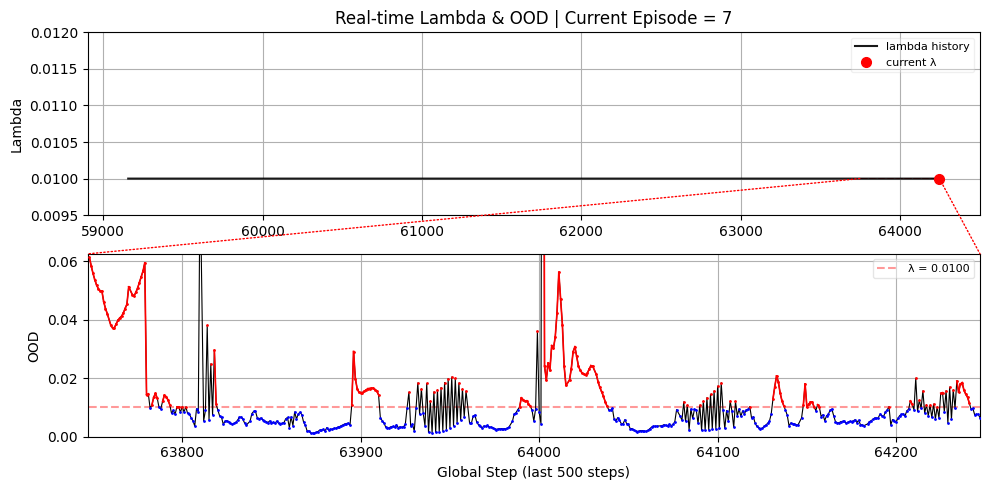

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import time, os
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

MAX_FILE_STEPS = 5000 # 최근 3000 step만 유지

log_path = "/AILAB-summer-school-2025/RND/ood_log.csv"
save_dir = "/AILAB-summer-school-2025/RND/plots"
os.makedirs(save_dir, exist_ok=True)

plt.ion()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,5), sharex=False)
disp = display(fig, display_id=True)

last_size = 0
STEP_WINDOW = 500   # only for OOD plot

zoom_patch = None
con_line1 = None
con_line2 = None

while True:
    try:
        current_size = os.path.getsize(log_path)
    except:
        time.sleep(0.5)
        continue

    if current_size == last_size:
        time.sleep(0.2)
        continue
    last_size = current_size

    # ============================================
    # 1) Load CSV (skip EPISODE_END)
    # ============================================
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("EPISODE_END"):
                continue

            parts = line.strip().split(",")
            if len(parts) != 4:
                continue

            try:
                rows.append([
                    int(parts[0]),   # global_step
                    float(parts[1]), # lambda
                    float(parts[2]), # ood
                    int(parts[3])    # episode
                ])
            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(rows,
                      columns=["global_step","lambda","ood","episode"])
    
    if df.shape[0] > MAX_FILE_STEPS:
        df = df.iloc[-MAX_FILE_STEPS:] 

        df.to_csv(log_path, index=False, header=False)

    latest_step   = df["global_step"].iloc[-1]
    latest_ep     = df["episode"].iloc[-1]
    latest_lambda = df["lambda"].iloc[-1]
    latest_ood    = df["ood"].iloc[-1]

    # ============================================
    # 2) 500-step sliding window (for OOD only)
    # ============================================
    window_min = max(0, latest_step - STEP_WINDOW)
    df_window = df[df["global_step"] >= window_min]

    # ============================================
    # 3) Lambda Plot (upper) - FULL HISTORY
    # ============================================
    ax1.clear()

    # 전체 히스토리 (회색)
    ax1.plot(df["global_step"],
             df["lambda"],
             color="black",
             alpha=0.9,
             label="lambda history")

    # 현재 lambda
    ax1.plot(latest_step,
             latest_lambda,
             'ro',
             markersize=7,
             label="current λ")

    # ✅ Outlier 제거용 Y축 설정
    lam_values = df["lambda"].values
    lam_p99 = np.percentile(lam_values, 99)
    lam_min = np.percentile(lam_values, 1)

    ax1.set_ylim(lam_min * 0.95, lam_p99 * 1.2)

    for p in list(ax1.patches):
        p.remove()

    zoom_patch = Rectangle(
        (window_min, lam_min),
        STEP_WINDOW,
        (lam_p99 - lam_min),
        linewidth=1.2,
        edgecolor="red",
        facecolor="none",
        linestyle="--"
    )
    ax1.add_patch(zoom_patch)

    ax1.set_ylabel("Lambda")
    ax1.set_title(f"Real-time Lambda & OOD | Current Episode = {latest_ep}")
    ax1.grid(True)
    ax1.legend(loc="upper right", fontsize=8, framealpha=0.3)
    # ============================================
    # 4) OOD Plot (lower) - SLIDING WINDOW
    # ============================================
    ax2.clear()

    ax2.plot(
        df_window["global_step"],
        df_window["lambda"],
        linestyle="--",
        color="red",
        alpha=0.4,
        label=f"λ = {latest_lambda:.4f}",
    )
    # ✅ OOD Y-axis clip
    ood_values = df_window["ood"].values
    if len(ood_values) > 5:
        ood_p99 = np.percentile(ood_values, 99)
        ymax = max(ood_p99 * 1.1, latest_lambda * 1.2)
        ax2.set_ylim(0, ymax)

    # ----- 에피소드별로 선/색 처리 -----
    for ep, ep_data in df_window.groupby("episode"):

        steps = ep_data["global_step"].values
        ood_vals = ep_data["ood"].values

        # 기본 선 (전체 trajectory는 유지)
        ax2.plot(steps, ood_vals, color="black", linewidth=0.8)

        # ✅ 현재 λ 보다 큰 지점만 빨간색으로 찍기
        exceed_mask = ood_vals > latest_lambda

        # 빨간 선 (연속된 구간)
        for i in range(len(steps) - 1):
            if exceed_mask[i] and exceed_mask[i+1]:
                ax2.plot(
                    steps[i:i+2],
                    ood_vals[i:i+2],
                    color="red",
                    linewidth=1.2
                )

        # # 빨간 점 (개별 point)
        ax2.scatter(
            steps[exceed_mask],
            ood_vals[exceed_mask],
            color="red",
            s=1,
            zorder=5
        )

        ax2.scatter(
            steps[ood_vals <= latest_lambda],
            ood_vals[ood_vals <= latest_lambda],
            color="blue",
            s=1,
            zorder=5
        )


    # X-limit only for sliding window
    ax2.set_xlim(window_min, latest_step)

    ax2.set_xlabel(f"Global Step (last {STEP_WINDOW} steps)")
    ax2.set_ylabel("OOD")
    ax2.grid(True)
    ax2.legend(loc="upper right", fontsize=8, framealpha=0.5)

    if con_line1 is not None:
        con_line1.remove()
    if con_line2 is not None:
        con_line2.remove()

    top_y = ax2.get_ylim()[1]

    con_line1 = ConnectionPatch(
        xyA=(window_min, lam_min), coordsA=ax1.transData,
        xyB=(window_min, top_y),   coordsB=ax2.transData,
        color="red",
        linestyle=":",
        linewidth=1
    )
    fig.add_artist(con_line1)

    con_line2 = ConnectionPatch(
        xyA=(latest_step, lam_min), coordsA=ax1.transData,
        xyB=(latest_step, top_y),   coordsB=ax2.transData,
        color="red",
        linestyle=":",
        linewidth=1
    )
    fig.add_artist(con_line2)

    plt.tight_layout()

    save_path = os.path.join(save_dir, "live_plot.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")

    disp.update(fig)
    time.sleep(0.1)